# Notebook 4 — Bayesian Inversion: Source Apportionment

**Prerequisites**: Run Notebooks 2 and 3 first.

---
### What are we doing and why?

We have two things from the previous notebooks:
- `T(t)` — the transport matrix at every timestamp (Notebook 2)
- `C(t)` — the observed PM2.5 at every station (Notebook 1)

The core equation is:

```
C = T · Q
```

We know `C` (sensors) and `T` (Gaussian plume model). We want `Q` (emission rates).

This is an **inverse problem** — going backwards from effects to causes.
It is harder than it sounds because:
1. The system is underdetermined: 14 unknowns, but sensors are correlated
2. Q must be ≥ 0 (you cannot emit negative pollution)
3. We want uncertainty estimates, not just a single number

**Bayesian inference** solves all three:
- It finds a *distribution* over Q, not just a point estimate
- The LogNormal prior enforces Q > 0
- The **fingerprinting enrichment** from Notebook 3 informs the prior — stations that empirically enrich many neighbours get a higher prior emission weight

---
### What is MCMC?

MCMC (Markov Chain Monte Carlo) explores the space of plausible Q values:

```
1. Start at a random Q vector
2. Compute how well T·Q matches observed C
3. Move toward better Q values (with some randomness to avoid local minima)
4. After thousands of steps, the path of Q values IS the posterior distribution
```

After sampling, we summarise with:
- **Posterior mean**: our best single estimate of Q
- **90% credible interval**: we are 90% confident the true Q falls here
- **R̂ (Gelman-Rubin)**: convergence check — should be < 1.01
- **ESS**: effective sample size — should be > 400

---
### Why 4-hour windows?

Emissions change slowly. A factory does not switch on/off every 15 minutes.
4-hour windows capture morning/afternoon/evening patterns while providing
enough data per window for stable inference.


## Block 1 — Matplotlib Setup (IEEE Style)

In [1]:
# 1. Importing style libraries
import matplotlib.pyplot as plt
import scienceplots

# 2. Configuring matplotlib for IEEE publication style
plt.style.use(["science", "no-latex"])
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "mathtext.default": "regular",
        "text.usetex": False,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.4,
        "xtick.direction": "in",
        "ytick.direction": "in",
    }
)

## Block 2 — Imports & Load All Previous Outputs

In [2]:
# 3. Importing all core libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import arviz as az
import pymc as pm
import pytensor.tensor as pt
from scipy.optimize import nnls

# 4. Configuring file paths — loading from Notebooks 2 and 3 output folders
NOTEBOOK_DIR = Path.cwd()
PHASE2_IN = NOTEBOOK_DIR / "data_prep"
PHASE3_IN = NOTEBOOK_DIR / "chemical_fingerprinting"
PHASE4_OUT = NOTEBOOK_DIR / "bayesian_inversion"
PHASE4_OUT.mkdir(exist_ok=True)


In [3]:
# 5. Loading all upstream outputs
T_tensor = np.load(PHASE2_IN / "T_tensor.npy")
C_wide = pd.read_parquet(PHASE2_IN / "C_matrix.parquet")
meta_df = pd.read_parquet(PHASE2_IN / "meta.parquet")
enrichment_mat = np.load(PHASE3_IN / "enrichment_matrix.npy")

STATION_NAMES = C_wide.columns.tolist()
N = len(STATION_NAMES)
times = C_wide.index
n_times = len(times)
short_names = [s[:10] for s in STATION_NAMES]

display(
    pd.DataFrame(
        {
            "T_tensor shape": [T_tensor.shape],
            "C_wide shape": [C_wide.shape],
            "enrichment_mat shape": [enrichment_mat.shape],
            "Stations": [N],
            "Timestamps": [n_times],
        }
    )
)

,T_tensor shape,C_wide shape,enrichment_mat shape,Stations,Timestamps
0,"(35040, 7, 7)","(35040, 7)","(7, 7)",7,35040


## Block 3 — Configuration

In [4]:
# 6. Setting all tunable parameters in one place
POLLUTANT = "pm25"
WINDOW_HOURS = 4  # each time window is 4 hours wide — one Q vector per window

# 7. MCMC settings
N_DRAWS = 1000  # posterior samples per chain — 1000 is a good starting point
N_TUNE = 500  # burn-in steps — discarded, used for sampler adaptation
N_CHAINS = 2  # independent chains — need ≥ 2 to compute R̂ convergence stat
TARGET_ACCEPT = 0.90  # NUTS acceptance rate — 0.90 means fine step sizes
RANDOM_SEED = 42  # for reproducibility

# 8. Prior settings — LogNormal: log(Q) ~ Normal(mu_log, sigma_log)
# LogNormal is ideal here because it naturally enforces Q > 0
# sigma_log = 1.5 means we allow Q to vary by ±exp(1.5) ≈ 4.5× from the prior mean
PRIOR_SIGMA_LOG = 1.5

# 9. Normalisation — T values are tiny (~1e-8), C values are ~100 µg/m³
# MCMC samplers work best when all variables are order-1
# We scale both so predictions land near 1.0 in normalised units
USE_SCALING = True

display(
    pd.DataFrame(
        {
            "Setting": [
                "Window hours",
                "MCMC draws",
                "MCMC tune",
                "MCMC chains",
                "Target accept",
                "Prior sigma_log",
                "Use scaling",
            ],
            "Value": [
                WINDOW_HOURS,
                N_DRAWS,
                N_TUNE,
                N_CHAINS,
                TARGET_ACCEPT,
                PRIOR_SIGMA_LOG,
                USE_SCALING,
            ],
            "Notes": [
                "4h = morning / afternoon / evening / night",
                "1000 = exploration; use 2000+ for publication",
                "500 burn-in steps discarded from posterior",
                "Need ≥ 2 for R̂ convergence diagnostic",
                "0.90 = conservative, avoids large leaps",
                "1.5 = Q can vary 4.5× from prior mean",
                "Always True unless debugging",
            ],
        }
    )
)

,Setting,Value,Notes
0,Window hours,4,4h = morning / afternoon / evening / night
1,MCMC draws,1000,1000 = exploration; use 2000+ for publication
2,MCMC tune,500,500 burn-in steps discarded from posterior
3,MCMC chains,2,Need ≥ 2 for R̂ convergence diagnostic
4,Target accept,0.9,"0.90 = conservative, avoids large leaps"
5,Prior sigma_log,1.5,1.5 = Q can vary 4.5× from prior mean
6,Use scaling,True,Always True unless debugging


## Block 4 — Build Fingerprint-Informed Prior

This is the key bridge between Notebook 3 and Notebook 4.

For each source station j, we compute its **source score** = mean enrichment it causes across all receptors.
- A station that consistently enriches many neighbours → likely a strong emitter → higher prior mean
- A station with no enrichment signal → prior mean is neutral (score = 1.0)

This is better than a flat prior because we are encoding what the data already told us.

**Example:**

| Station | Enriches other stations? | Source score | log(score) = mu_prior |
|---|---|---|---|
| Jigani | Yes — scores 1.8, 2.1, 1.6 on 3 receptors | 1.83 | +0.60 |
| SilkBoard | No consistent signal | 1.02 | +0.02 |


/tmp/ipykernel_10075/2040077732.py:4: RuntimeWarning: Mean of empty slice
  source_score = np.nanmean(enrichment_mat, axis=0)   # (N,)


,Source score,mu_log_prior
Station,,
BTMLayout,1.098,0.094
Hebbal,0.736,-0.307
Jigani,1.000,0.000
KasturiNagar,0.870,-0.139
RvceMailasandra,1.096,0.092
ShivapuraPeenya,1.150,0.140
SilkBoard,0.960,-0.041


/tmp/ipykernel_10075/2040077732.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(STATION_NAMES, rotation=45, ha="right", fontsize=8)


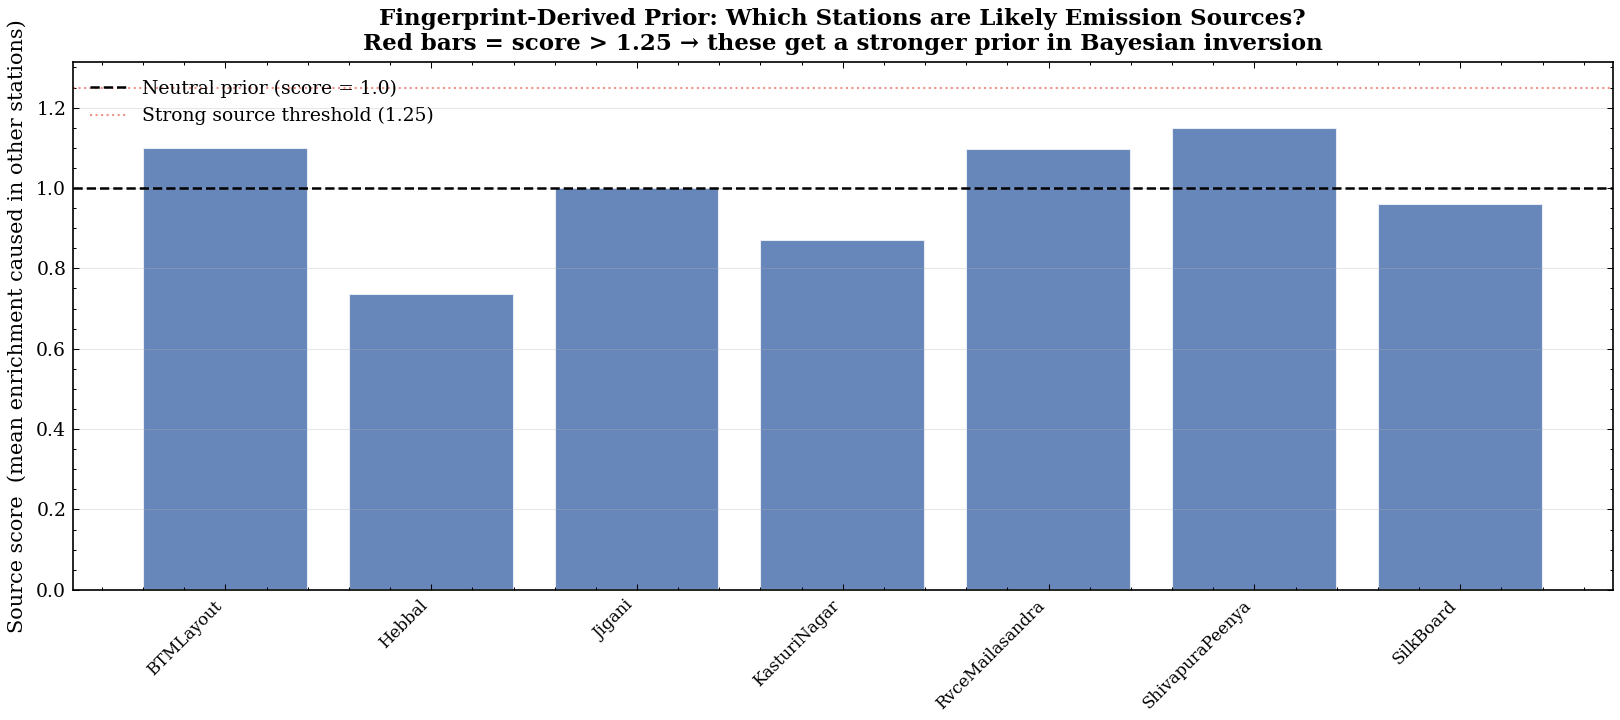

In [ ]:
# 10. Computing source score = mean enrichment each station j causes in all receptors i
# enrichment_mat[i, j] = how much station j enriches receptor i
# nanmean over axis=0 → average across all receptors for each source
source_score = np.nanmean(enrichment_mat, axis=0)  # (N,)

# 11. Replacing NaN scores (too few data) with 1.0 — neutral prior
source_score = np.where(np.isnan(source_score), 1.0, source_score)

# 12. Converting to log-scale prior mean
# score=1.0 → mu_log=0.0 (Q ~ exp(0) = 1 in normalised units)
# score=1.5 → mu_log=log(1.5)≈0.4 (Q is expected to be 50% higher)
mu_log_prior = np.log(source_score)  # (N,)

# 13. Showing the prior for each station as a bar chart
display(
    pd.DataFrame(
        {
            "Station": STATION_NAMES,
            "Source score": source_score.round(3),
            "mu_log_prior": mu_log_prior.round(3),
        }
    ).set_index("Station")
)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#e74c3c" if s > 1.25 else "#4C72B0" for s in source_score]
ax.bar(STATION_NAMES, source_score, color=colors, alpha=0.85, edgecolor="white")
ax.axhline(1.0, color="black", lw=1.2, ls="--", label="Neutral prior (score = 1.0)")
ax.axhline(
    1.25,
    color="#e74c3c",
    lw=1.0,
    ls=":",
    alpha=0.6,
    label="Strong source threshold (1.25)",
)
ax.set_xticklabels(STATION_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Source score  (mean enrichment caused in other stations)")
ax.set_title(
    "Fingerprint-Derived Prior: Which Stations are Likely Emission Sources?\n"
    "Red bars = score > 1.25 → these get a stronger prior in Bayesian inversion",
    fontweight="bold",
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PHASE4_OUT / "fig_prior_source_scores.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 5 — Build Time Windows

,Total timestamps,Window size,Total windows,Min ts/window,Median ts/window,Max ts/window
0,35040,4h,2190,16,16,16


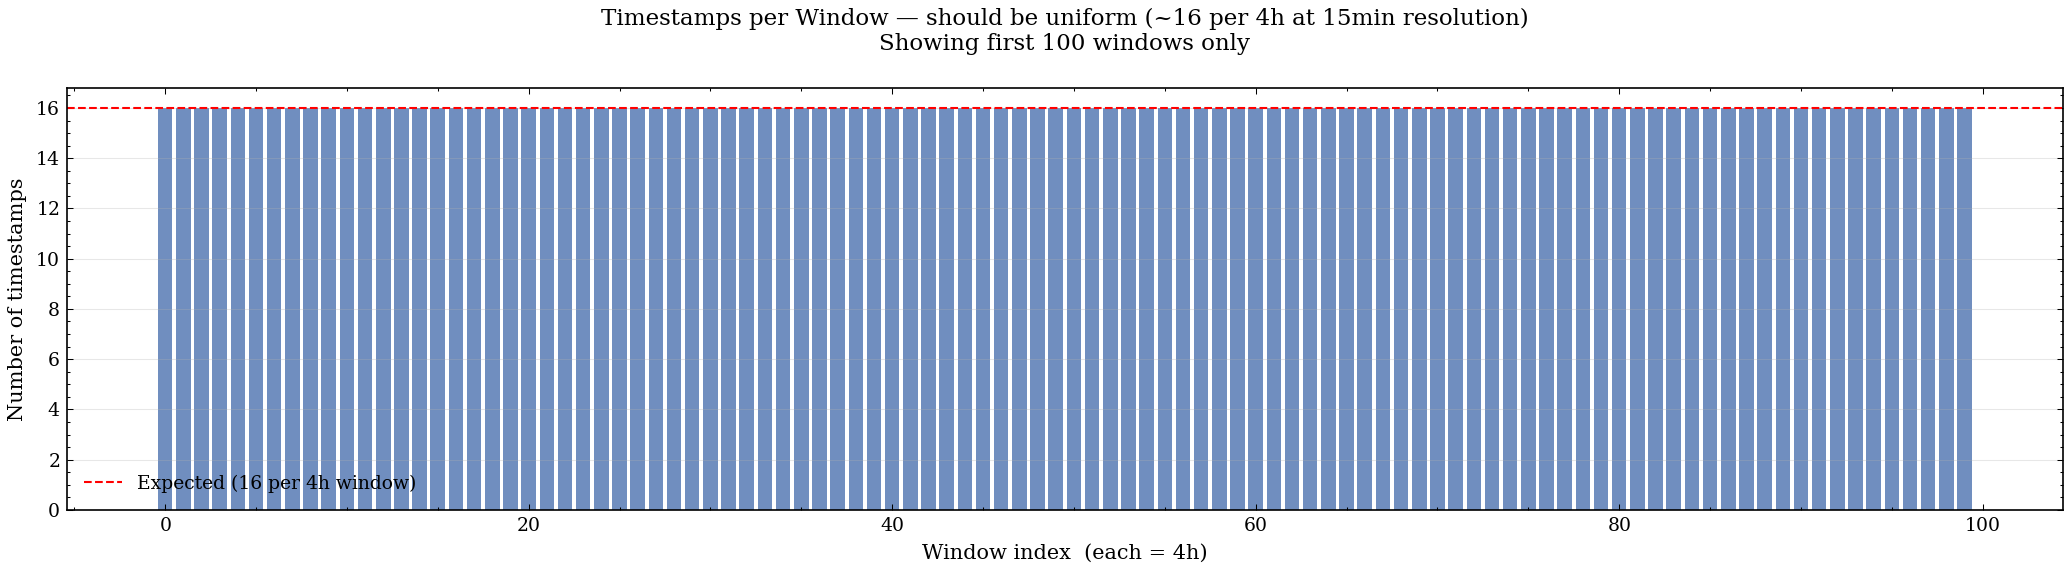

In [6]:
# 14. Assigning each timestamp to a 4-hour window
# Window 0 = hours 0-4, Window 1 = hours 4-8, ... etc., globally unique across days
hours_arr = meta_df["hour"].values
days_arr = (times - times[0]).total_seconds().values / 86400  # fractional day
window_id = (days_arr * 24 / WINDOW_HOURS).astype(int)

unique_windows = np.unique(window_id)
n_windows = len(unique_windows)
window_idx = np.searchsorted(unique_windows, window_id)  # maps to 0..n_windows-1

# 15. Reporting window statistics
ts_per_window = np.bincount(window_idx)
display(
    pd.DataFrame(
        {
            "Total timestamps": [n_times],
            "Window size": [f"{WINDOW_HOURS}h"],
            "Total windows": [n_windows],
            "Min ts/window": [ts_per_window.min()],
            "Median ts/window": [int(np.median(ts_per_window))],
            "Max ts/window": [ts_per_window.max()],
        }
    )
)

# 16. Visualising the window structure as a bar chart
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(min(n_windows, 100)), ts_per_window[:100], color="#4C72B0", alpha=0.8)
ax.set_xlabel(f"Window index  (each = {WINDOW_HOURS}h)")
ax.set_ylabel("Number of timestamps")
ax.set_title(
    "Timestamps per Window — should be uniform (~16 per 4h at 15min resolution)\n"
    "Showing first 100 windows only\n"
    if n_windows > 100
    else "Timestamps per Window — should be uniform (~16 per 4h at 15min resolution)\n"
)
ax.axhline(16, color="red", ls="--", lw=1, label="Expected (16 per 4h window)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PHASE4_OUT / "fig_window_structure.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 6 — Normalise T and C for MCMC

In [7]:
# 17. Converting to float32 to save memory — float64 doubles the tensor size for no gain
C_arr = C_wide.values.astype(np.float32)  # (n_times, N)

if USE_SCALING:
    # 18. Scaling T by its 95th percentile — robust to rare extreme transport events
    # Scaling C by its 95th percentile — robust to pollution spikes
    T_scale = np.percentile(T_tensor[T_tensor > 0], 95)
    C_scale = np.percentile(C_arr[C_arr > 0], 95)

    T_norm = (T_tensor / T_scale).astype(np.float32)
    C_norm = (C_arr / C_scale).astype(np.float32)
else:
    T_norm = T_tensor.astype(np.float32)
    C_norm = C_arr.astype(np.float32)
    T_scale = 1.0
    C_scale = 1.0

display(
    pd.DataFrame(
        {
            "Variable": ["T_tensor", "C_wide", "T_norm", "C_norm"],
            "Min": [T_tensor.min(), C_arr.min(), T_norm.min(), C_norm.min()],
            "Max": [T_tensor.max(), C_arr.max(), T_norm.max(), C_norm.max()],
            "Units": ["µg/m³ per g/s", "µg/m³", "normalised", "normalised"],
        }
    ).round(5)
)

,Variable,Min,Max,Units
0,T_tensor,0.00000,432.250885,µg/m³ per g/s
1,C_wide,2.00000,997.989990,µg/m³
2,T_norm,0.00000,55.473610,normalised
3,C_norm,0.01051,5.245400,normalised


## Block 7 — Simple Bayesian Model (Single Window Baseline)

**Before running the full multi-window model, we validate on one window first.**

This is a standard scientific practice: verify the math is correct on a small case
before scaling up. If this window converges cleanly, the full model will too.

We use the **first time window** as the test case.

### The model in full:

```
Q_j ~ LogNormal(mu_log_prior[j], sigma_log)     for each station j

For each timestamp t in window 0:
    C_predicted[t, i] = sum_j  T[t, i, j] * Q_j
    C_observed[t, i]  ~ Normal(C_predicted[t, i], sigma_obs)

sigma_obs ~ HalfNormal(0.5)    # sensor noise — also inferred
```


In [8]:
# 19. Selecting data for the first window only
w0_mask = window_idx == 0
T_w0 = T_norm[w0_mask]  # (n_ts_w0, N, N)
C_w0 = C_norm[w0_mask]  # (n_ts_w0, N)
n_ts_w0 = w0_mask.sum()

display(
    pd.DataFrame(
        {
            "Window 0 timestamps": [n_ts_w0],
            "T_w0 shape": [T_w0.shape],
            "C_w0 shape": [C_w0.shape],
            "C_w0 mean": [f"{C_w0.mean():.3f}  (normalised)"],
            "C_w0 max": [f"{C_w0.max():.3f}  (normalised)"],
        }
    )
)

,Window 0 timestamps,T_w0 shape,C_w0 shape,C_w0 mean,C_w0 max
0,16,"(16, 7, 7)","(16, 7)",0.557 (normalised),0.809 (normalised)


In [9]:
# 20. Building and sampling the simple single-window Bayesian model
with pm.Model() as simple_model:
    # 21. Prior on emission rates — LogNormal with fingerprint-informed mean
    # Q > 0 always because LogNormal output is always positive
    # mu = mu_log_prior[j]: informed by how much j empirically enriches others
    Q = pm.LogNormal("Q", mu=mu_log_prior, sigma=PRIOR_SIGMA_LOG, shape=N)

    # 22. Forward model: C_predicted[t, i] = sum_j T[t, i, j] * Q[j]
    # T_w0 is (n_ts, N, N), Q is (N,) → pt.dot gives (n_ts, N)
    C_pred = pt.dot(T_w0, Q)

    # 23. Observation noise — also inferred from data, not fixed
    # HalfNormal ensures sigma_obs > 0
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.5)

    # 24. Likelihood — connects the model to the data
    # 'observed=C_w0' tells PyMC this is data, not a latent variable to sample
    C_like = pm.Normal("C_obs", mu=C_pred, sigma=sigma_obs, observed=C_w0)

    # 25. MAP estimate first — a fast point estimate before running MCMC
    # MAP = Maximum A Posteriori — finds the Q that maximises the posterior
    # This is like a sanity check: if MAP looks wrong, MCMC will also be wrong
    map_est = pm.find_MAP()
    Q_map = map_est["Q"] * (C_scale / T_scale)

    display(
        pd.DataFrame(
            {
                "Station": STATION_NAMES,
                "Q_MAP (g/s)": Q_map.round(4),
            }
        )
        .set_index("Station")
        .sort_values("Q_MAP (g/s)", ascending=False)
    )

    # 26. MCMC sampling using NUTS (No-U-Turn Sampler)
    # NUTS is PyMC's default and state-of-the-art for continuous parameters
    trace_simple = pm.sample(
        draws=N_DRAWS,
        tune=N_TUNE,
        chains=N_CHAINS,
        cores=1,
        target_accept=TARGET_ACCEPT,
        progressbar=True,
        return_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Output()

,Q_MAP (g/s)
Station,
Jigani,165.2934
KasturiNagar,7.5320
ShivapuraPeenya,2.9597
BTMLayout,2.8267
RvceMailasandra,2.8219
SilkBoard,2.4698
Hebbal,1.8936


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [Q, sigma_obs]


Output()

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


## Block 8 — Convergence Diagnostics

**Before looking at any results, we must verify the sampler converged.**

If R̂ > 1.01 or ESS < 400, the posterior estimates are unreliable.
Common fixes: more tune steps, higher target_accept, or simpler model.

| Diagnostic | Good value | Meaning |
|---|---|---|
| R̂ (Gelman-Rubin) | < 1.01 | Multiple chains agree |
| ESS bulk | > 400 | Enough independent samples |
| ESS tail | > 400 | Tail behaviour is stable |
| Trace plot | Fuzzy caterpillar | No trends or drift |


In [10]:
# 27. R̂ and ESS summary table
diag = az.summary(trace_simple, var_names=["Q"], kind="diagnostics")
display(diag)

rhat_vals = diag["r_hat"].values.astype(float)
ess_bulk = diag["ess_bulk"].values.astype(float)

n_bad_rhat = int((rhat_vals > 1.01).sum())
n_bad_ess = int((ess_bulk < 400).sum())

display(
    pd.DataFrame(
        {
            "Diagnostic": ["R̂ > 1.01 (bad)", "ESS < 400 (bad)"],
            "Count": [n_bad_rhat, n_bad_ess],
            "Out of": [N, N],
            "Status": [
                "✓ All converged"
                if n_bad_rhat == 0
                else f"⚠ {n_bad_rhat} not converged — increase N_TUNE",
                "✓ Sufficient samples"
                if n_bad_ess == 0
                else f"⚠ {n_bad_ess} low ESS — increase N_DRAWS",
            ],
        }
    )
)

,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Q[0],1923,1511,1.00,0.21,1.3
Q[1],2027,1523,1.00,0.11,0.57
Q[2],951,557,1.00,0.072,0.054
Q[3],1676,904,1.00,0.0059,0.0042
Q[4],2503,1489,1.00,0.2,1.1
Q[5],2777,1292,1.00,0.28,1.8
Q[6],1773,1487,1.00,0.15,0.52


,Diagnostic,Count,Out of,Status
0,R̂ > 1.01 (bad),0,7,✓ All converged
1,ESS < 400 (bad),0,7,✓ Sufficient samples


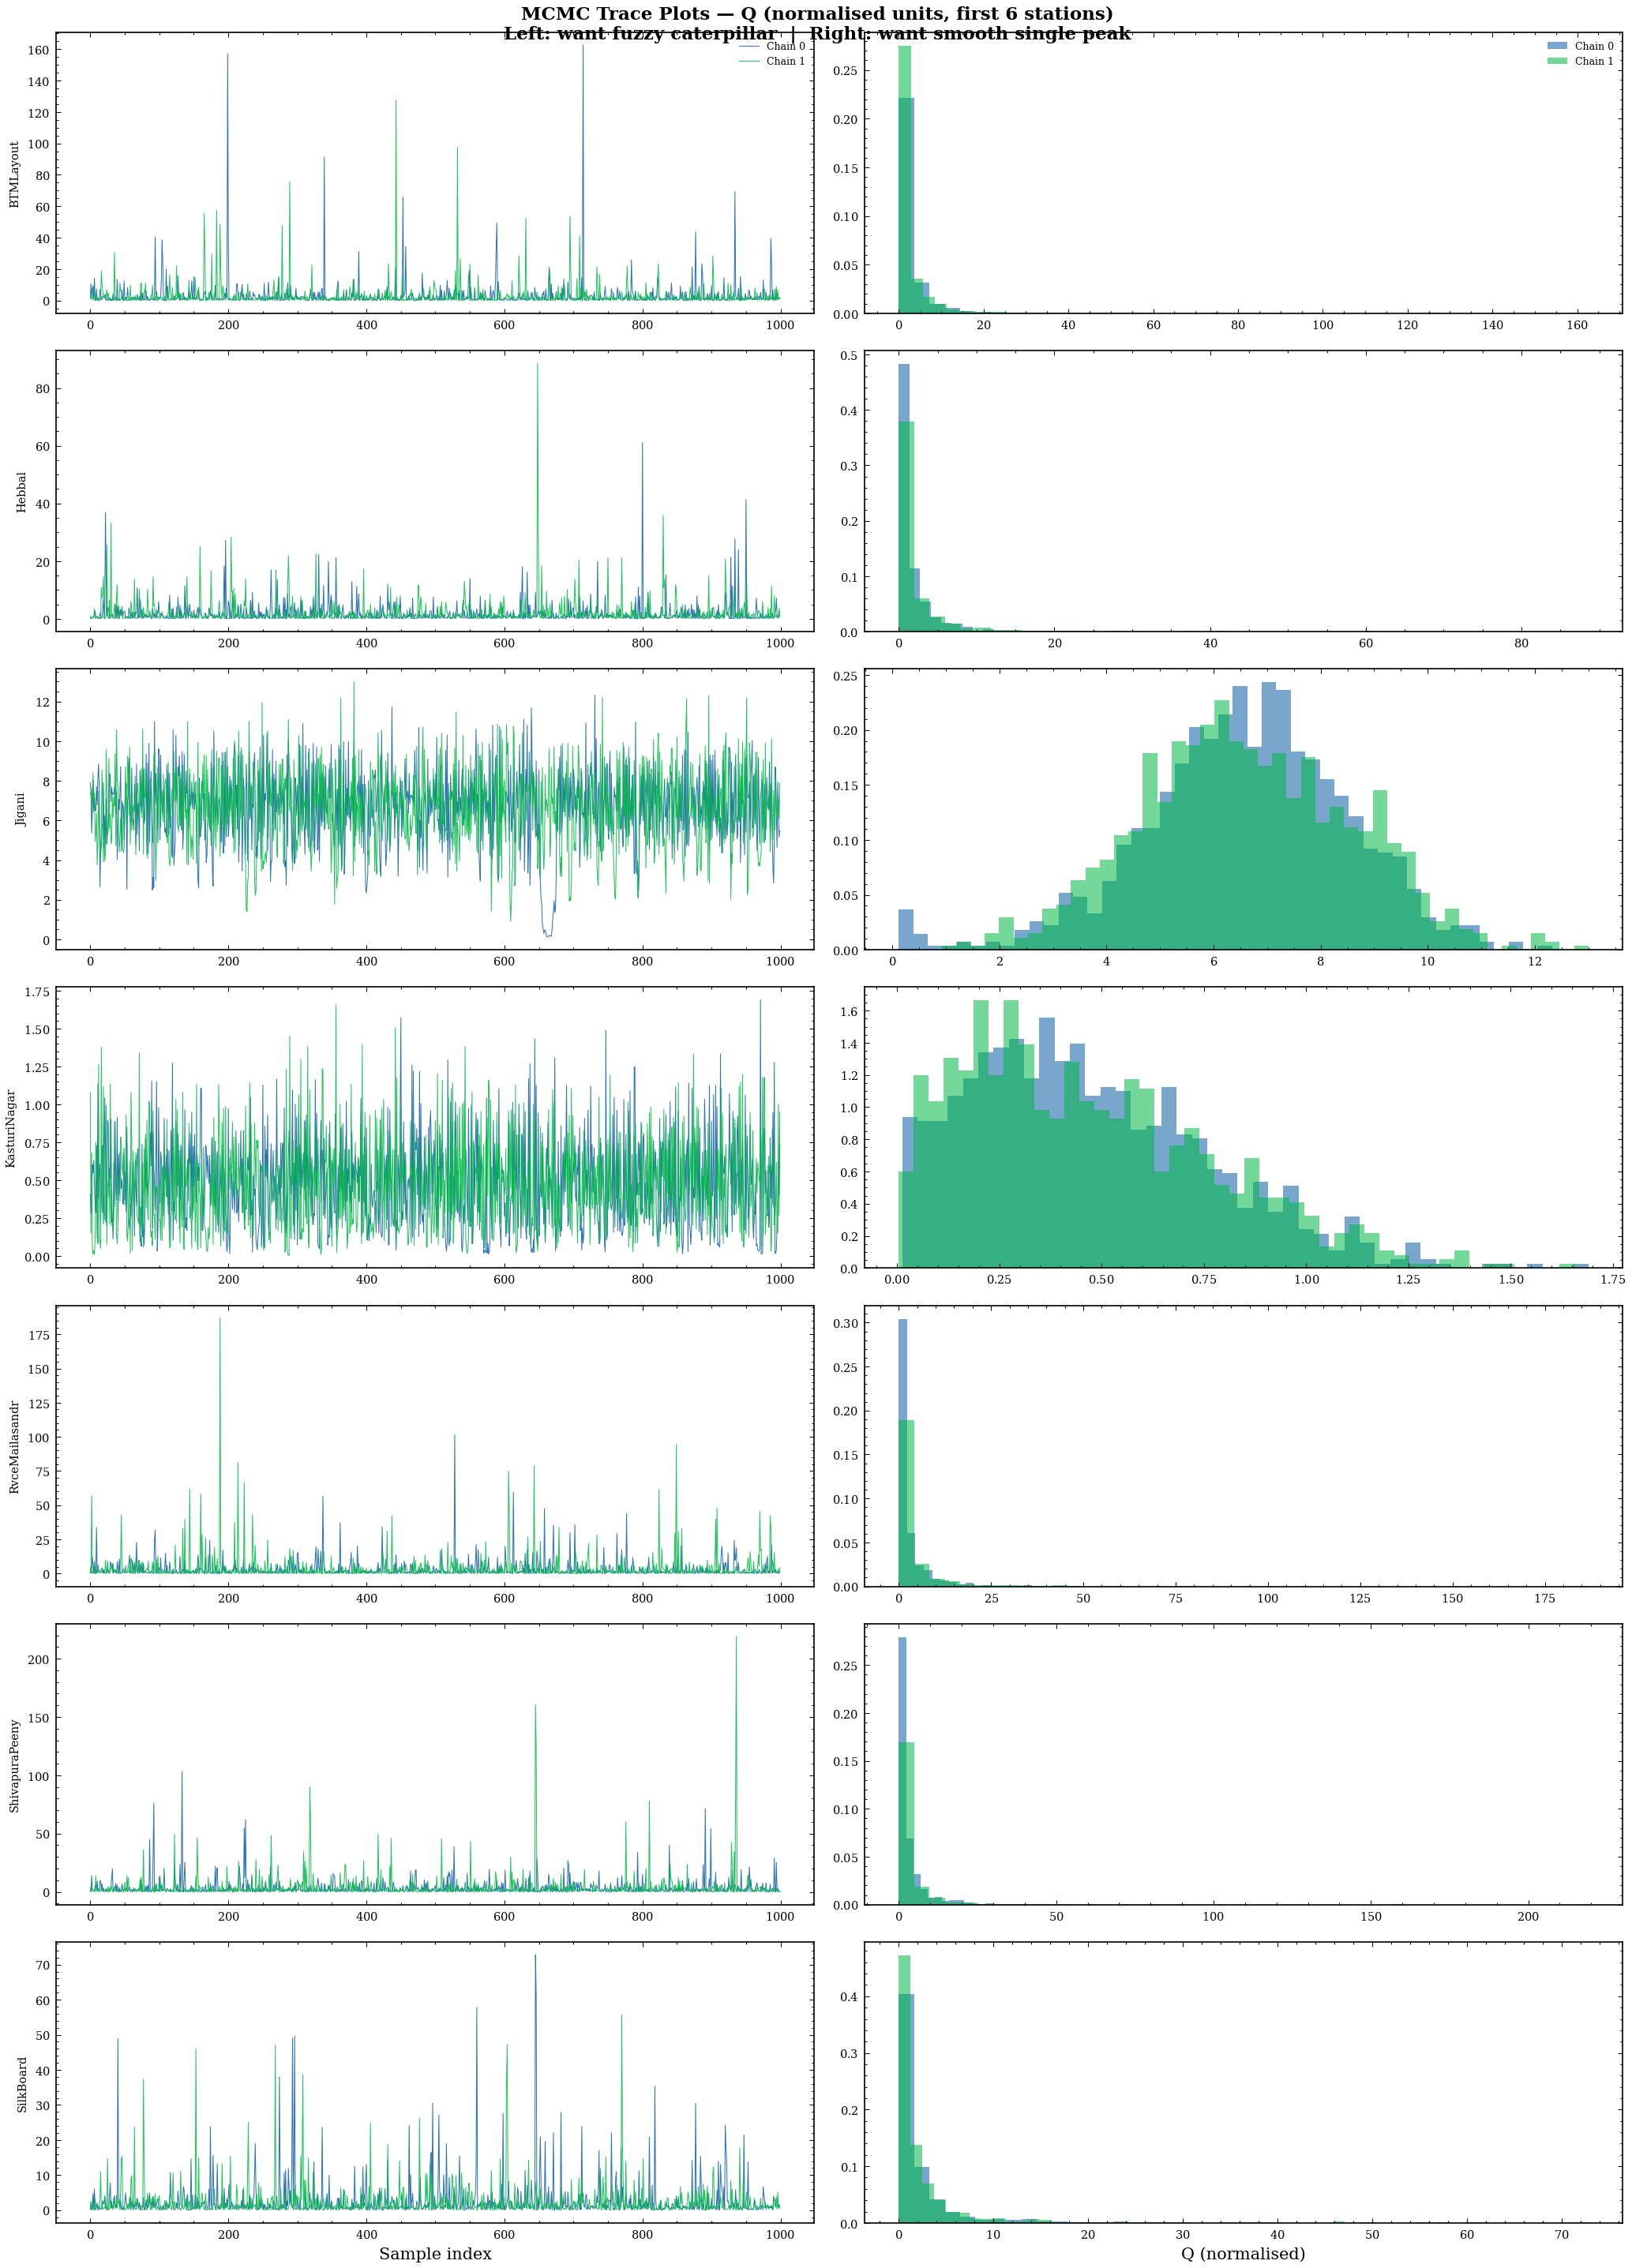

In [12]:
# 28. Trace plots for the first 6 stations
# Left column = trace (chain trajectory over sampling steps)
# Right column = posterior density histogram
# Good trace: looks like a "fuzzy caterpillar" — no trends, no drift, overlapping chains
Q_post = trace_simple.posterior["Q"].values  # (n_chains, n_draws, N)

fig, axes = plt.subplots(N, 2, figsize=(14, 2.8 * N))
fig.suptitle(
    "MCMC Trace Plots — Q (normalised units, first 6 stations)\n"
    "Left: want fuzzy caterpillar  |  Right: want smooth single peak",
    fontsize=11,
    fontweight="bold",
)

for k in range(N):
    samples_k = Q_post[:, :, k]  # (n_chains, n_draws)

    # 29. Left panel — trace
    ax_t = axes[k, 0]
    for ch in range(samples_k.shape[0]):
        ax_t.plot(samples_k[ch], lw=0.5, alpha=0.85, label=f"Chain {ch}")
    ax_t.set_ylabel(STATION_NAMES[k][:14], fontsize=7)
    ax_t.tick_params(labelsize=7)
    if k == 0:
        ax_t.legend(fontsize=6, loc="upper right")
    if k == N - 1:
        ax_t.set_xlabel("Sample index")

    # 30. Right panel — density
    ax_d = axes[k, 1]
    for ch in range(samples_k.shape[0]):
        ax_d.hist(samples_k[ch], bins=45, alpha=0.55, density=True, label=f"Chain {ch}")
    ax_d.tick_params(labelsize=7)
    if k == 0:
        ax_d.legend(fontsize=6, loc="upper right")
    if k == N - 1:
        ax_d.set_xlabel("Q (normalised)")

plt.tight_layout()
plt.savefig(PHASE4_OUT / "fig_trace_simple.png", dpi=100, bbox_inches="tight")
plt.show()

## Block 9 — Posterior: Credible Intervals

The posterior gives us a **distribution** over Q, not just one number.

- **90% credible interval**: we are 90% confident the true Q lies within this range
- **Wider bar** = more uncertainty (few observations or weak signal for that station)
- **MAP** = single best point estimate (Maximum A Posteriori)
- **NNLS** = non-negative least squares baseline (no probability, just algebra)

Comparing Bayesian vs NNLS: if they agree, our prior is not dominating the posterior.


In [13]:
# 31. Rescaling posterior from normalised units back to approximate g/s
Q_rescaled = Q_post * (C_scale / T_scale)  # (n_chains, n_draws, N)

Q_mean = Q_rescaled.mean(axis=(0, 1))  # (N,)
Q_lo = np.percentile(Q_rescaled, 5, axis=(0, 1))  # 5th percentile
Q_hi = np.percentile(Q_rescaled, 95, axis=(0, 1))  # 95th percentile

# 32. NNLS baseline — classic non-negative least squares (no uncertainty, no prior)
T_w0_mean = T_tensor[w0_mask].mean(axis=0)  # average T over the window
C_w0_mean = C_arr[w0_mask].mean(axis=0)  # average C over the window
Q_nnls, _ = nnls(T_w0_mean, C_w0_mean)

# 33. Summary table: Bayesian mean vs NNLS vs MAP
display(
    pd.DataFrame(
        {
            "Station": STATION_NAMES,
            "Q_Bayes_mean": Q_mean.round(4),
            "Q_lo_5pct": Q_lo.round(4),
            "Q_hi_95pct": Q_hi.round(4),
            "Q_MAP": Q_map.round(4),
            "Q_NNLS": Q_nnls.round(4),
        }
    )
    .set_index("Station")
    .sort_values("Q_Bayes_mean", ascending=False)
)

,Q_Bayes_mean,Q_lo_5pct,Q_hi_95pct,Q_MAP,Q_NNLS
Station,,,,,
Jigani,161.1637,82.1384,235.9973,165.2934,0.000000e+00
ShivapuraPeenya,92.7833,2.1646,344.6757,2.9597,0.000000e+00
RvceMailasandra,87.1262,2.3415,331.6652,2.8219,0.000000e+00
BTMLayout,75.1900,2.0954,270.3855,2.8267,0.000000e+00
SilkBoard,61.7999,1.9384,256.2352,2.4698,0.000000e+00
Hebbal,49.6595,1.6947,192.0351,1.8936,1.079600e+06
KasturiNagar,11.4796,1.7158,24.8082,7.5320,1.684544e+02


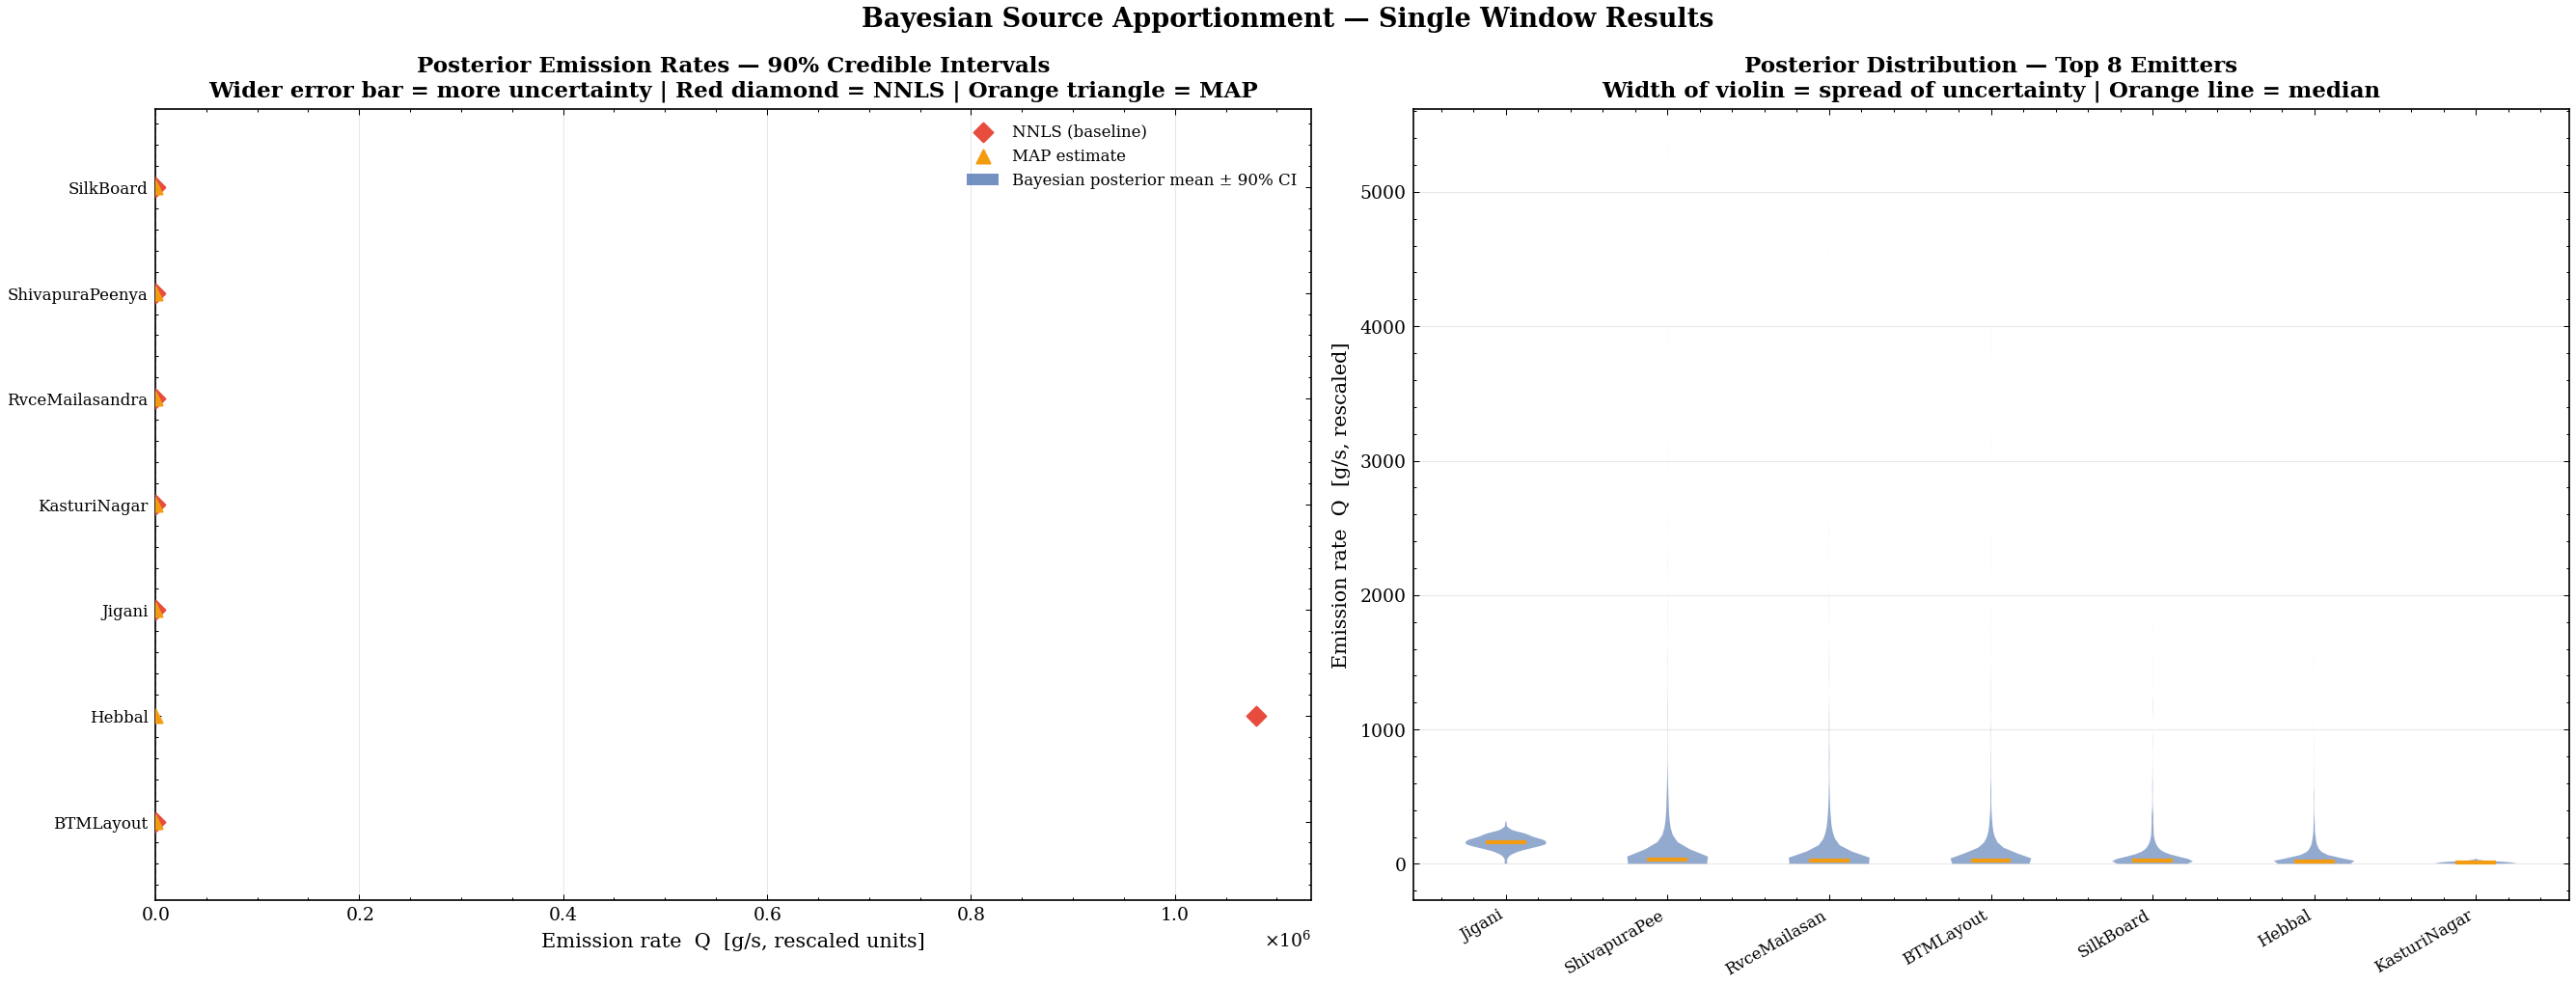

In [15]:
# 34. Two-panel figure: credible interval bars (left) + violin plots for top emitters (right)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 35. Left panel — horizontal bar chart with 90% credible intervals
ax = axes[0]
y_pos = np.arange(N)
ax.barh(
    y_pos,
    Q_mean,
    xerr=[Q_mean - Q_lo, Q_hi - Q_mean],
    align="center",
    alpha=0.78,
    color="#4C72B0",
    error_kw=dict(elinewidth=1.5, capsize=4, ecolor="#2c4e80"),
    label="Bayesian posterior mean ± 90% CI",
)
ax.scatter(
    Q_nnls, y_pos, color="#e74c3c", zorder=5, s=45, marker="D", label="NNLS (baseline)"
)
ax.scatter(
    Q_map, y_pos, color="#f39c12", zorder=6, s=45, marker="^", label="MAP estimate"
)
ax.set_yticks(y_pos)
ax.set_yticklabels(STATION_NAMES, fontsize=8)
ax.set_xlabel("Emission rate  Q  [g/s, rescaled units]")
ax.set_title(
    "Posterior Emission Rates — 90% Credible Intervals\n"
    "Wider error bar = more uncertainty | Red diamond = NNLS | Orange triangle = MAP",
    fontweight="bold",
)
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)
ax.axvline(0, color="gray", lw=0.8, ls="--")

# 36. Right panel — violin plots for top 8 stations by posterior mean
ax2 = axes[1]
top8_idx = np.argsort(Q_mean)[-8:][::-1]
data_violin = [Q_rescaled[:, :, k].flatten() for k in top8_idx]
labels_v = [STATION_NAMES[k][:12] for k in top8_idx]

parts = ax2.violinplot(
    data_violin, positions=range(len(top8_idx)), showmedians=True, showextrema=False
)
for pc in parts["bodies"]:
    pc.set_facecolor("#4C72B0")
    pc.set_alpha(0.60)
parts["cmedians"].set_color("#f39c12")
parts["cmedians"].set_linewidth(2)

ax2.set_xticks(range(len(top8_idx)))
ax2.set_xticklabels(labels_v, rotation=30, ha="right", fontsize=8)
ax2.set_ylabel("Emission rate  Q  [g/s, rescaled]")
ax2.set_title(
    "Posterior Distribution — Top 8 Emitters\n"
    "Width of violin = spread of uncertainty | Orange line = median",
    fontweight="bold",
)
ax2.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Bayesian Source Apportionment — Single Window Results",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(PHASE4_OUT / "fig_posterior_simple.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 10 — Reconstruction Quality Check

How well does our inferred Q reproduce the **observed** PM2.5 concentrations?

`C_reconstructed = T · Q_mean`

If reconstruction is good → the Gaussian plume model + Bayesian Q explains the data well.
If reconstruction is poor → there are local sources, chemistry effects, or terrain the model misses.
We also compare against NNLS to see whether the Bayesian approach improves the fit.


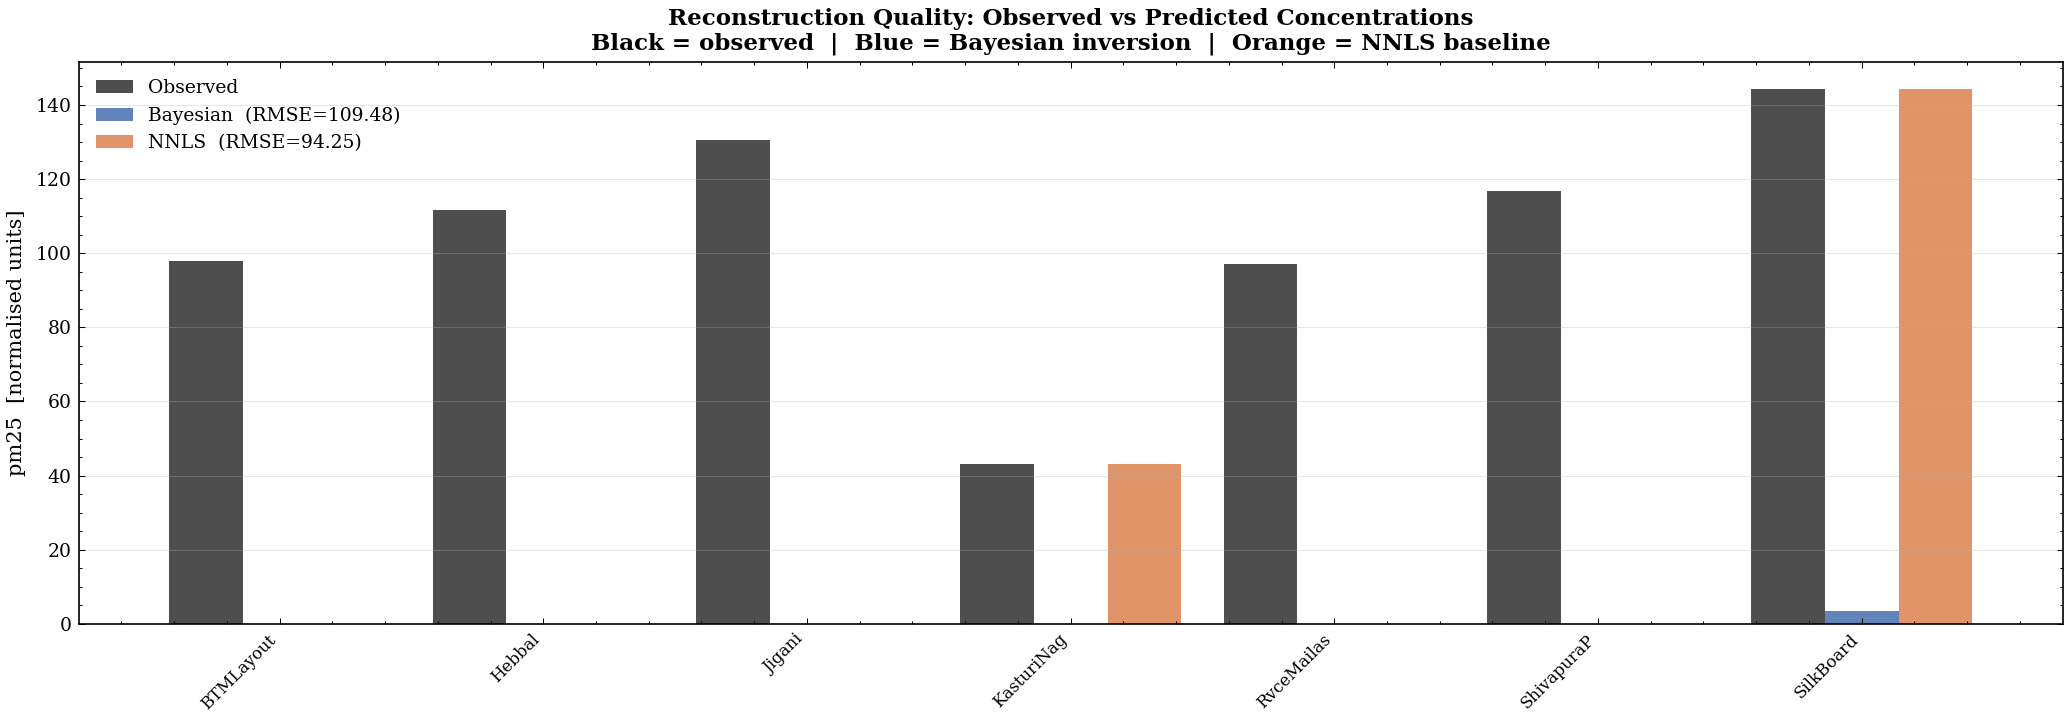

,Method,RMSE,Better?
0,Bayesian inversion,109.4848,✗
1,NNLS baseline,94.2498,✓


In [16]:
# 37. Computing reconstructed concentrations using Bayesian Q_mean and NNLS Q
C_obs_w0 = C_arr[w0_mask].mean(axis=0)  # mean observed over window 0
C_pred_bay = T_w0_mean @ (Q_mean / (C_scale / T_scale))  # Bayesian reconstruction
C_pred_nnls = T_w0_mean @ Q_nnls  # NNLS reconstruction

rmse_bay = np.sqrt(np.mean((C_obs_w0 - C_pred_bay) ** 2))
rmse_nnls = np.sqrt(np.mean((C_obs_w0 - C_pred_nnls) ** 2))

# 38. Side-by-side bar chart comparing observed vs Bayesian vs NNLS
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(N)
w = 0.28
ax.bar(x - w, C_obs_w0, width=w, label="Observed", alpha=0.87, color="#333333")
ax.bar(
    x,
    C_pred_bay,
    width=w,
    label=f"Bayesian  (RMSE={rmse_bay:.2f})",
    alpha=0.87,
    color="#4C72B0",
)
ax.bar(
    x + w,
    C_pred_nnls,
    width=w,
    label=f"NNLS  (RMSE={rmse_nnls:.2f})",
    alpha=0.87,
    color="#DD8452",
)
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel(f"{POLLUTANT}  [normalised units]")
ax.set_title(
    "Reconstruction Quality: Observed vs Predicted Concentrations\n"
    "Black = observed  |  Blue = Bayesian inversion  |  Orange = NNLS baseline",
    fontweight="bold",
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PHASE4_OUT / "fig_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()

display(
    pd.DataFrame(
        {
            "Method": ["Bayesian inversion", "NNLS baseline"],
            "RMSE": [f"{rmse_bay:.4f}", f"{rmse_nnls:.4f}"],
            "Better?": [
                "✓" if rmse_bay < rmse_nnls else "✗",
                "✓" if rmse_nnls <= rmse_bay else "✗",
            ],
        }
    )
)

## Block 11 — Time-Windowed Bayesian: Q Across All Windows

Now we run the full version: estimate Q for **every time window**.

We run each window independently — this is "embarrassingly parallel"
but we do it sequentially here to keep things simple.

**Output**: `Q_time_mean[w, j]` = emission rate of station j in time window w

> ⚠️ **Time warning**: This runs one MCMC per window.
> At ~20-30s per window, 24 windows = ~10 minutes.
> Set `MAX_WINDOWS` below to a smaller number for quick exploration.


In [17]:
# 39. Limiting to MAX_WINDOWS for fast exploration
# Set MAX_WINDOWS = n_windows to run the full dataset
MAX_WINDOWS = min(24, n_windows)

# 40. Storage arrays — NaN means "window was skipped (too few timestamps)"
Q_time_mean = np.full((MAX_WINDOWS, N), np.nan)
Q_time_lo = np.full((MAX_WINDOWS, N), np.nan)
Q_time_hi = np.full((MAX_WINDOWS, N), np.nan)

display(
    pd.DataFrame(
        {
            "Total windows available": [n_windows],
            "Running this session": [MAX_WINDOWS],
            "Estimated time (min)": [
                f"~{MAX_WINDOWS * 25 // 60}–{MAX_WINDOWS * 35 // 60}"
            ],
        }
    )
)

,Total windows available,Running this session,Estimated time (min)
0,2190,24,~10–14


In [18]:
# 41. Main time-windowed loop — one MCMC model per window
for w in tqdm(range(MAX_WINDOWS), desc="Time windows"):
    mask = window_idx == w
    n_ts_w = mask.sum()

    # 42. Skipping windows with fewer than 2 timestamps — MCMC cannot run on 1 point
    if n_ts_w < 2:
        continue

    T_w = T_norm[mask]  # (n_ts_w, N, N)
    C_w = C_norm[mask]  # (n_ts_w, N)

    try:
        with pm.Model():
            Q_w = pm.LogNormal("Q", mu=mu_log_prior, sigma=PRIOR_SIGMA_LOG, shape=N)
            C_pred_w = pt.dot(T_w, Q_w)
            sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.5)
            pm.Normal("C_obs", mu=C_pred_w, sigma=sigma_obs, observed=C_w)

            # 43. Using fewer draws per window for speed — 500 is enough for time-series trends
            trace_w = pm.sample(
                draws=500,
                tune=250,
                chains=2,
                cores=1,
                target_accept=TARGET_ACCEPT,
                progressbar=False,  # suppress per-window bars — outer tqdm shows progress
                return_inferencedata=True,
                random_seed=RANDOM_SEED + w,
            )

        # 44. Rescaling back to original units and storing percentiles
        Q_post_w = trace_w.posterior["Q"].values * (C_scale / T_scale)
        Q_time_mean[w] = Q_post_w.mean(axis=(0, 1))
        Q_time_lo[w] = np.percentile(Q_post_w, 5, axis=(0, 1))
        Q_time_hi[w] = np.percentile(Q_post_w, 95, axis=(0, 1))

    except Exception as e:
        # 45. Logging failures without stopping the loop — some windows may have bad data
        display(pd.DataFrame({"Window": [w], "Error": [str(e)]}))

Time windows:   0%|          | 0/24 [00:00<?, ?it/s]Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [Q, sigma_obs]
Sampling 2 chains for 250 tune and 500 draw iterations (500 + 1_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Time windows:   4%|▍         | 1/24 [00:01<00:43,  1.87s/it]Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [Q, sigma_obs]
Sampling 2 chains for 250 tune and 500 draw iterations (500 + 1_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Time windows:   8%|▊         | 2/24 [00:04<00:45,  2.06s/it]Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [Q, sigma_obs]
Sampling 2 chains for 250 tune and 500 draw iterations (500 + 1_000 draws total) took 1 seconds.
We recommend running at least 4 chains fo

## Block 12 — Visualise Time-Varying Emissions

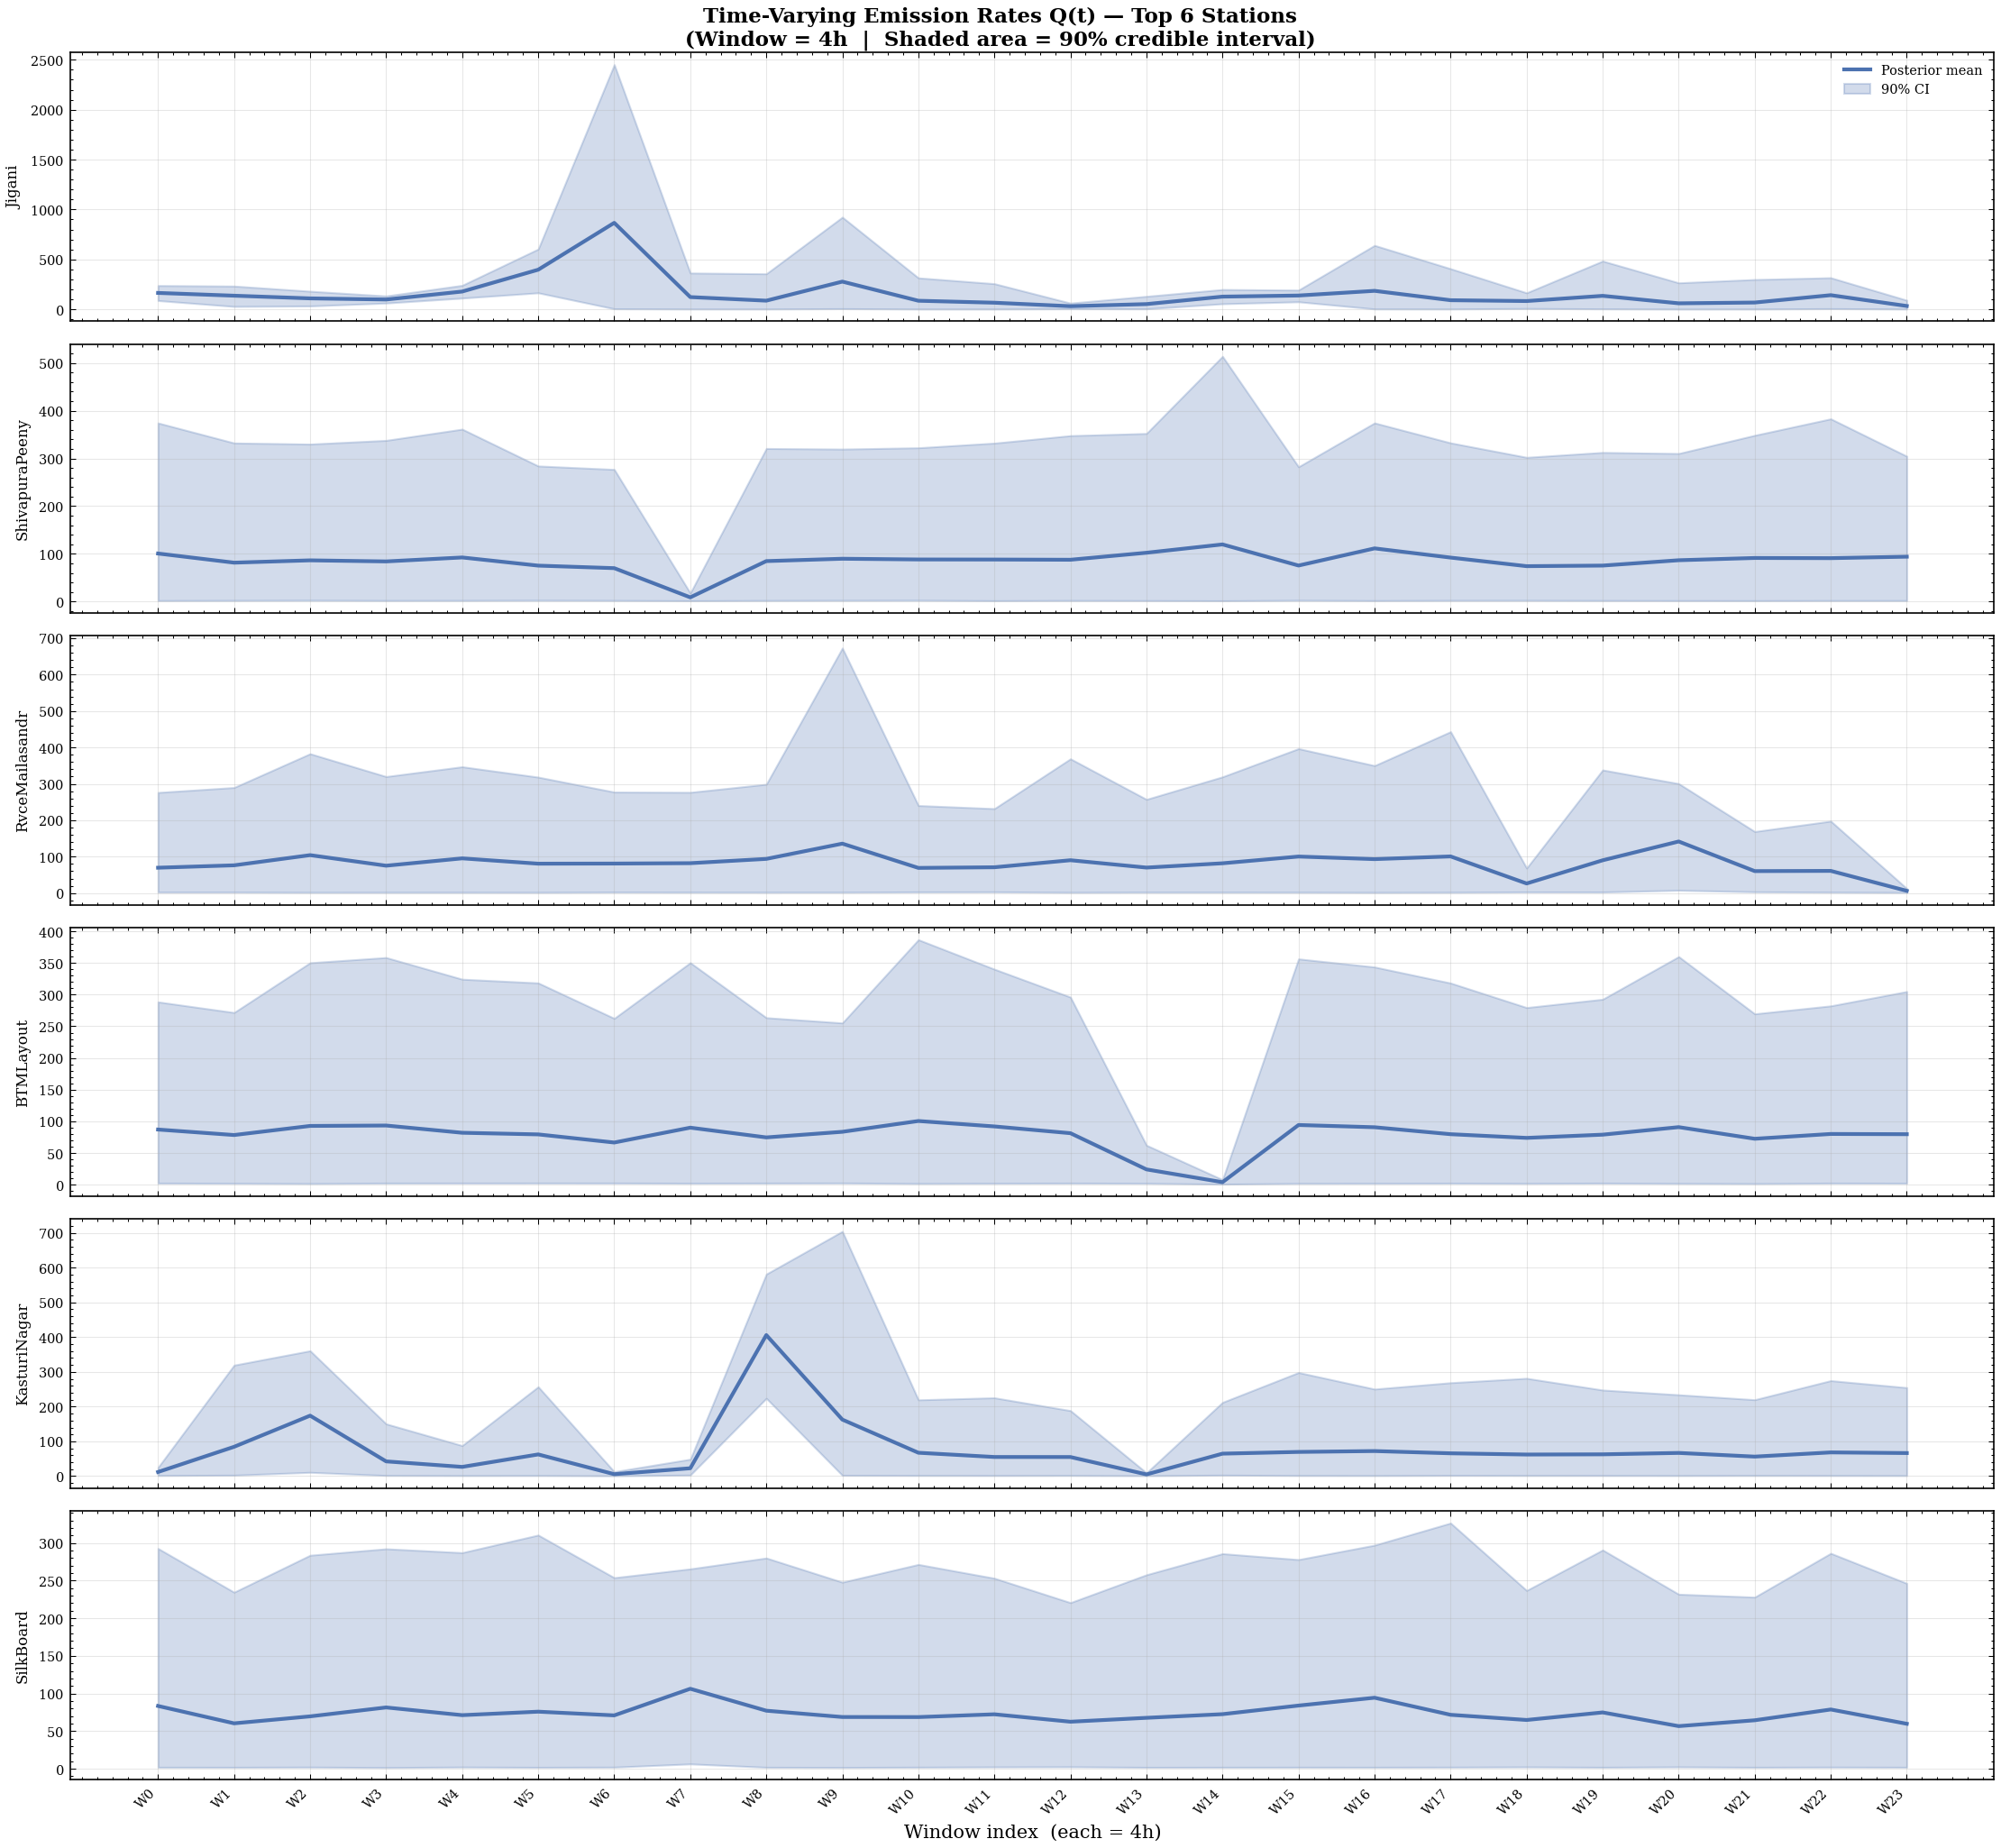

In [19]:
# 46. Time series of Q(t) for the top 6 stations by mean emission over all windows
# Shaded area = 90% credible interval at each window
mean_Q_overall = np.nanmean(Q_time_mean, axis=0)  # (N,)
top6_idx = np.argsort(mean_Q_overall)[-6:][::-1]

fig, axes = plt.subplots(6, 1, figsize=(15, 14), sharex=True)
fig.suptitle(
    f"Time-Varying Emission Rates Q(t) — Top 6 Stations\n"
    f"(Window = {WINDOW_HOURS}h  |  Shaded area = 90% credible interval)",
    fontsize=11,
    fontweight="bold",
)
x_vals = np.arange(MAX_WINDOWS)

for row, k in enumerate(top6_idx):
    ax = axes[row]
    mean_k = Q_time_mean[:, k]
    lo_k = Q_time_lo[:, k]
    hi_k = Q_time_hi[:, k]

    ax.plot(x_vals, mean_k, color="#4C72B0", lw=2.0, label="Posterior mean")
    ax.fill_between(x_vals, lo_k, hi_k, alpha=0.25, color="#4C72B0", label="90% CI")
    ax.set_ylabel(STATION_NAMES[k][:14], fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)
    if row == 0:
        ax.legend(fontsize=7, loc="upper right")

axes[-1].set_xlabel(f"Window index  (each = {WINDOW_HOURS}h)")
if MAX_WINDOWS <= 48:
    axes[-1].set_xticks(x_vals)
    axes[-1].set_xticklabels(
        [f"W{w}" for w in range(MAX_WINDOWS)], rotation=45, ha="right", fontsize=7
    )
plt.tight_layout()
plt.savefig(PHASE4_OUT / "fig_time_varying_Q.png", dpi=150, bbox_inches="tight")
plt.show()

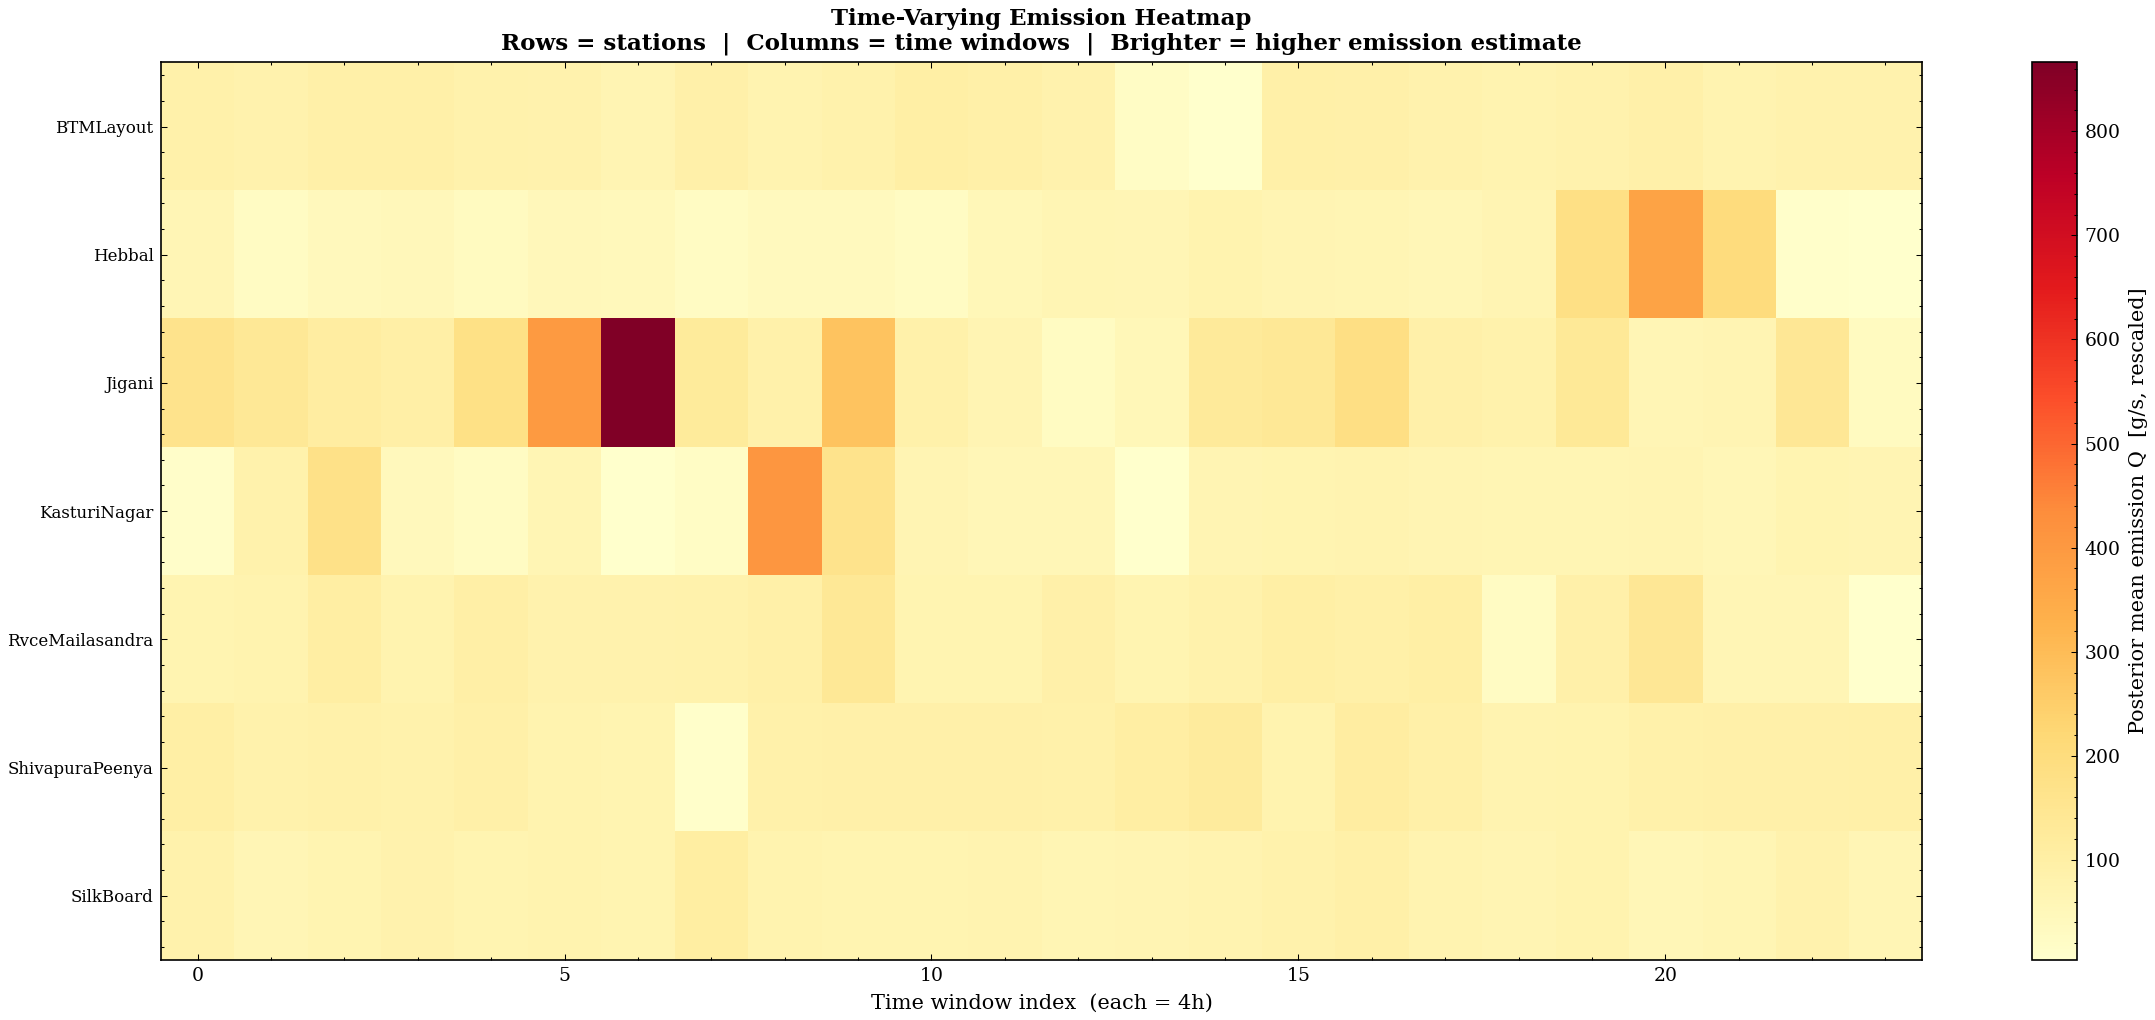

In [20]:
# 47. Heatmap of Q_time_mean — rows = stations, columns = time windows
# This is the most information-dense summary of the entire Bayesian analysis
# Bright yellow-red = high emission at that station in that window
# Dark = low emission or not running

fig, ax = plt.subplots(figsize=(16, 7))
im = ax.imshow(
    Q_time_mean.T,  # transpose: rows=stations, cols=windows
    aspect="auto",
    cmap="YlOrRd",
    interpolation="nearest",
)
plt.colorbar(im, ax=ax, label="Posterior mean emission Q  [g/s, rescaled]")
ax.set_yticks(range(N))
ax.set_yticklabels(STATION_NAMES, fontsize=8)
ax.set_xlabel(f"Time window index  (each = {WINDOW_HOURS}h)")
ax.set_title(
    "Time-Varying Emission Heatmap\n"
    "Rows = stations  |  Columns = time windows  |  Brighter = higher emission estimate",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(PHASE4_OUT / "fig_Q_heatmap_time.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 13 — Export Results

In [22]:
# 48. Saving all windowed Q estimates to disk for downstream analysis
np.save(PHASE4_OUT / "Q_time_mean.npy", Q_time_mean)
np.save(PHASE4_OUT / "Q_time_lo.npy", Q_time_lo)
np.save(PHASE4_OUT / "Q_time_hi.npy", Q_time_hi)

# 49. Saving a human-readable CSV: rows = windows, columns = stations
pd.DataFrame(Q_time_mean, columns=STATION_NAMES).to_csv(
    PHASE4_OUT / "Q_time_mean.csv", index=True
)

# 50. Summary table: overall mean emission per station (averaged across all windows)
summary_df = (
    pd.DataFrame(
        {
            "station": STATION_NAMES,
            "Q_overall_mean": np.nanmean(Q_time_mean, axis=0).round(4),
            "Q_overall_lo_5": np.nanmean(Q_time_lo, axis=0).round(4),
            "Q_overall_hi_95": np.nanmean(Q_time_hi, axis=0).round(4),
            "source_score": source_score.round(3),
        }
    )
    .sort_values("Q_overall_mean", ascending=False)
    .reset_index(drop=True)
)

summary_df.to_csv(PHASE4_OUT / "source_apportionment_summary.csv", index=False)

display(summary_df)
display(
    pd.DataFrame(
        {
            "File": [
                "Q_time_mean.npy",
                "Q_time_lo.npy",
                "Q_time_hi.npy",
                "Q_time_mean.csv",
                "source_apportionment_summary.csv",
            ],
            "Contents": [
                f"Posterior mean Q — shape ({MAX_WINDOWS}, {N})",
                f"5th percentile Q — shape ({MAX_WINDOWS}, {N})",
                f"95th percentile Q — shape ({MAX_WINDOWS}, {N})",
                f"Human-readable CSV — {MAX_WINDOWS} rows X {N} stations",
                f"Per-station summary across all {MAX_WINDOWS} windows",
            ],
        }
    )
)

,station,Q_overall_mean,Q_overall_lo_5,Q_overall_hi_95,source_score
0,Jigani,155.1490,27.9838,397.5120,1.000
1,ShivapuraPeenya,85.5787,2.3206,323.9533,1.150
2,RvceMailasandra,81.4477,2.5850,298.1444,1.096
3,BTMLayout,77.9156,2.2245,289.3660,1.098
4,KasturiNagar,76.5194,11.5066,239.0149,0.870
5,SilkBoard,73.2026,2.1775,269.1466,0.960
6,Hebbal,71.0101,13.7204,213.6600,0.736


,File,Contents
0,Q_time_mean.npy,"Posterior mean Q — shape (24, 7)"
1,Q_time_lo.npy,"5th percentile Q — shape (24, 7)"
2,Q_time_hi.npy,"95th percentile Q — shape (24, 7)"
3,Q_time_mean.csv,Human-readable CSV — 24 rows X 7 stations
4,source_apportionment_summary.csv,Per-station summary across all 24 windows
